In [9]:
import os
import json
import inspect
import torch
import numpy as np
import pandas as pd

from pathlib import Path
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from sunpy.visualization.colormaps import color_tables

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm, patch_attn_layers, visualize_head
from sdofmv2.utils import ALL_COMPONENTS

In [4]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_HMI.yaml"
    )

In [7]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

cache_dir = "../../../assets/cache/HMI/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    hmi_mask=cache_dir + "hmi_mask_512x512.npy",
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

2026-06-05 02:07:57.249 | INFO     | sdofmv2.core.datamodule:setup:635 - Train dataloader is ready!
2026-06-05 02:07:57.256 | INFO     | sdofmv2.core.datamodule:setup:636 - Dataset size: 284813
2026-06-05 02:07:57.282 | INFO     | sdofmv2.core.datamodule:setup:654 - Validation dataloader is ready!
2026-06-05 02:07:57.283 | INFO     | sdofmv2.core.datamodule:setup:655 - Dataset size: 30533
2026-06-05 02:07:57.307 | INFO     | sdofmv2.core.datamodule:setup:673 - test dataloader is ready!
2026-06-05 02:07:57.311 | INFO     | sdofmv2.core.datamodule:setup:674 - Dataset size: 31570


In [18]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
ckpt = torch.load(ckpt_dir + "HMI/id_mycczy8p_mae_epoch=299-val_loss=0.03.ckpt", map_location="cpu", weights_only=False)
hyper_parameters = ckpt["hyper_parameters"]

# Get MAE.__init__ argument names (excluding self)
valid_args = set(inspect.signature(MAE.__init__).parameters.keys()) - {"self"}

# Keep only parameters accepted by MAE
model_hparams = {k: v for k, v in hyper_parameters.items() if k in valid_args}
model_hparams["mask_only_inner"] = True
model = MAE(**model_hparams)
model.load_state_dict(ckpt["state_dict"], strict=False)


_IncompatibleKeys(missing_keys=['disk_mask', 'autoencoder.limb_mask', 'autoencoder.patch_off_limb_mask'], unexpected_keys=[])

In [ ]:

# model = MAE.load_from_checkpoint(
#     checkpoint_path= ckpt_dir + "HMI/id_mycczy8p_mae_epoch=299-val_loss=0.03.ckpt", 
#     map_location="cpu",
#     weights_only=False)
# model.eval()

# model_loss_inner_only = MAE.load_from_checkpoint(
#     checkpoint_path= ckpt_dir + "HMI/id_do2piiw5_mae_epoch=96-val_loss=0.00.ckpt", 
#     map_location="cpu",
#     weights_only=False)
# model_loss_inner_only.eval()

RuntimeError: Error(s) in loading state_dict for MAE:
	Missing key(s) in state_dict: "disk_mask", "autoencoder.limb_mask", "autoencoder.patch_off_limb_mask". 
	Unexpected key(s) in state_dict: "autoencoder.ids_limb_mask". 

In [19]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    "2014-12-25 00:12:00",
    "2015-12-25 00:12:00",
    "2016-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00'), Timestamp('2014-12-25 00:12:00'), Timestamp('2015-12-25 00:12:00'), Timestamp('2016-12-25 00:12:00')]


In [20]:
hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

# inverse transformation of hmi
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(hmi_list):

        x_set[i_img, ch_id, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

In [21]:
attn_maps = patch_attn_layers(model)

with torch.no_grad():
    latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set, mask_ratio=0)

In [22]:
def get_mean_pulled_head_attn(attn_maps, img_index):
    attn = attn_maps[0][img_index, :, 1:, 1:]
    num_heads = attn.shape[0]
    full_order = torch.argsort(ids_restore[img_index])  # Invert argsort
    num_kept = attn.shape[1]
    ids_keep = full_order[:num_kept]
    attn_received = attn.mean(axis=1)

    return attn_received, ids_keep

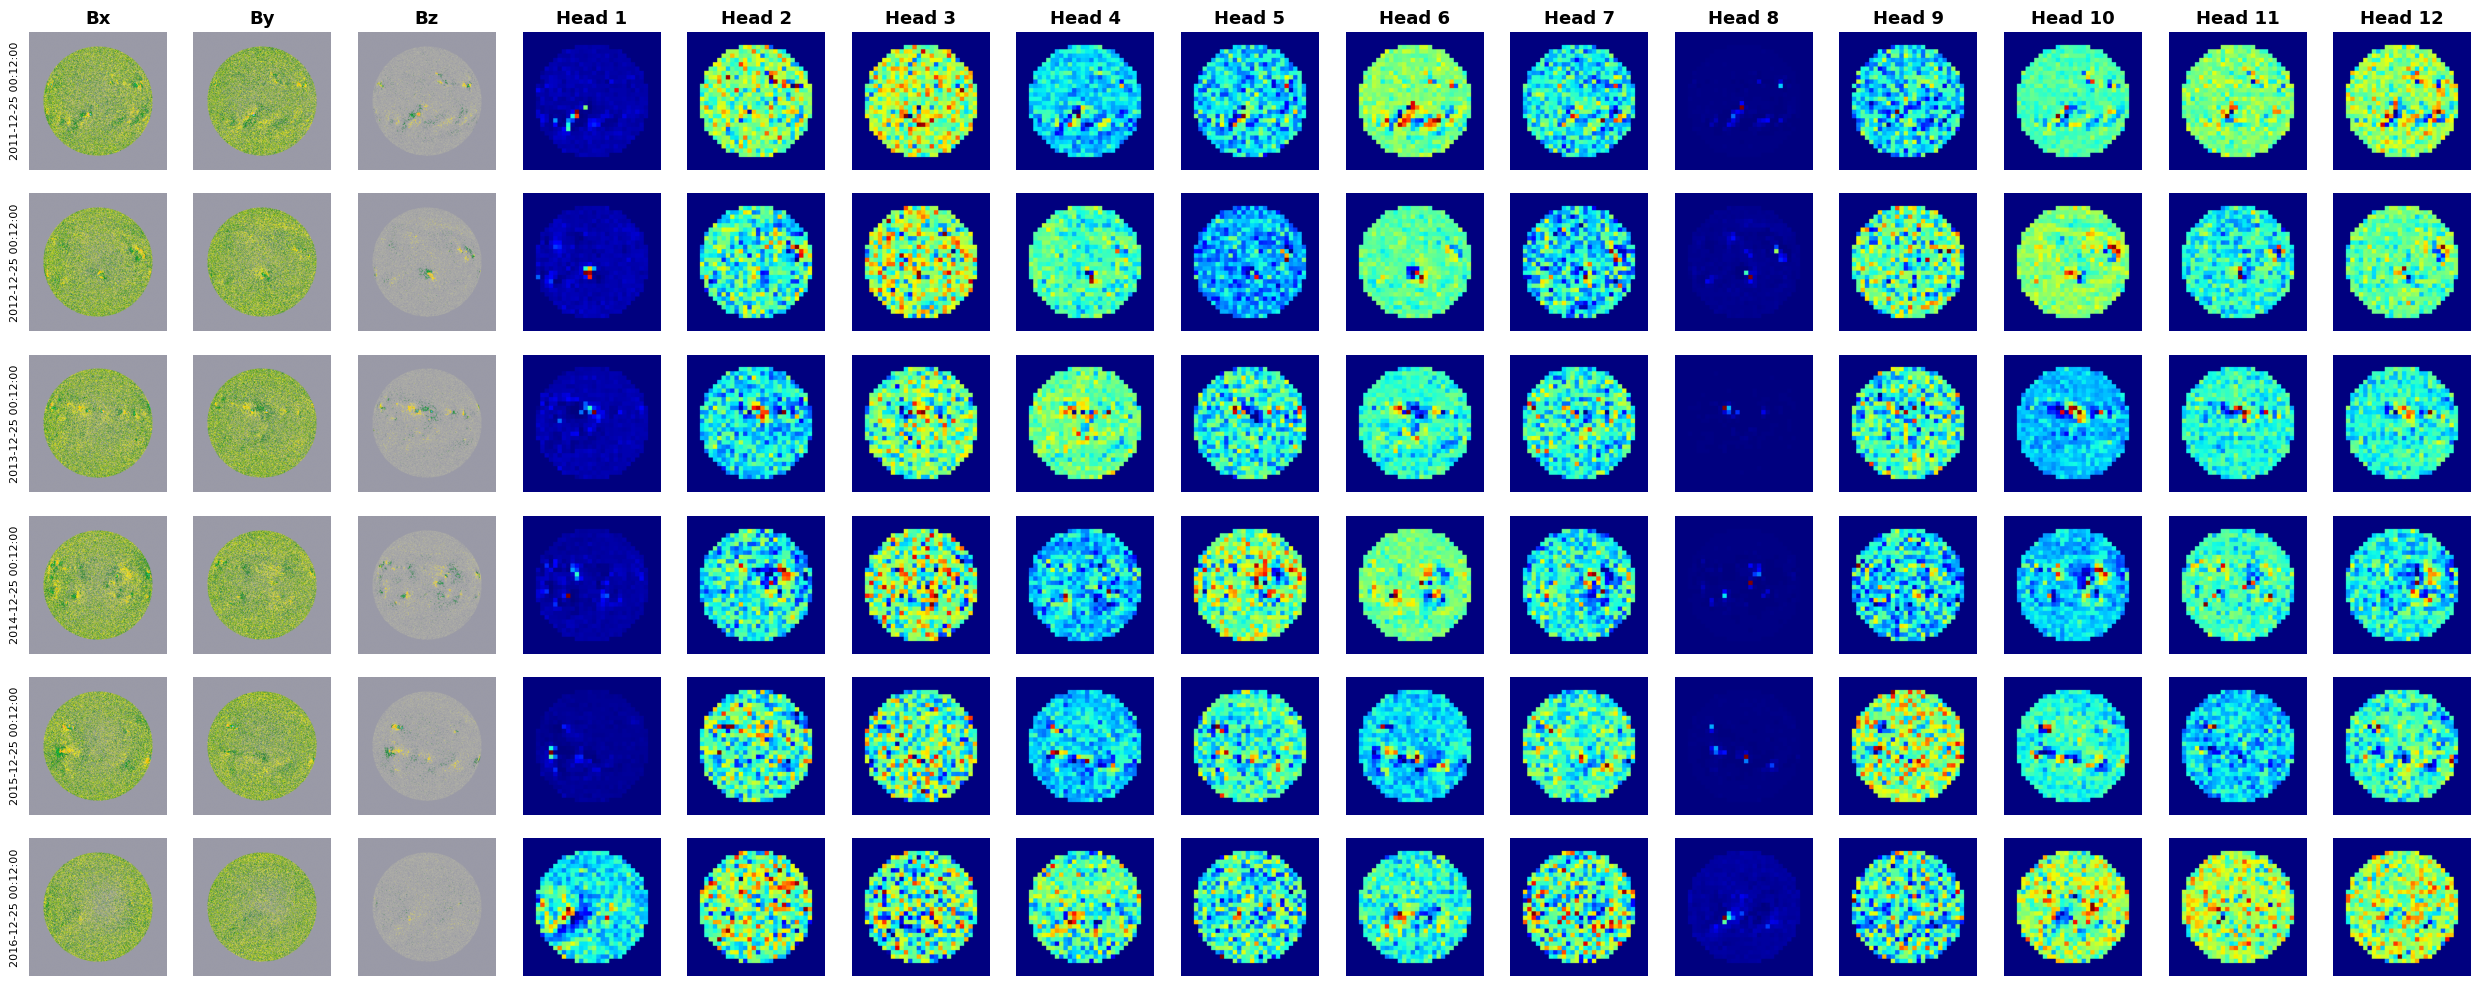

In [23]:
num_images = x_set.shape[0]
num_channels = x_set.shape[1]
num_heads = attn_maps[0].shape[1]
hmi_cmap= color_tables.hmi_mag_color_table()
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

fig, axs = plt.subplots(
    num_images, num_heads + num_channels, figsize=(25, 10), squeeze=False
)

for i in range(num_images):

    attn_received, ids_keep  = get_mean_pulled_head_attn(attn_maps, i)

    for i_col, ch in enumerate(hmi_list):
        if i == 0:
            axs[i, i_col].set_title(f"{ch}", fontsize=13, fontweight='bold')

        axs[i, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)
        # axs[i+num_images, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)
        axs[i, i_col].axis("off")
        # axs[i+num_images, i_col].axis("off")


    for h in range(num_heads):
        if i == 0:
            axs[i, h+num_channels].set_title(f"Head {h+1}", fontsize=13, fontweight='bold')
            
        head_attn = attn_received[h, :]
        heatmap = visualize_head(head_attn, ids_keep, 512, 16)
        axs[i, h+num_channels].imshow(heatmap, cmap="jet")
        axs[i, h+num_channels].axis("off")

    axs[i][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[i]}", 
        ha='center', 
        va='center', 
        fontsize=8, 
        rotation=90,
        transform=axs[i][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.tight_layout()
plt.savefig("attention_map_HMI.pdf", dpi=300, bbox_inches="tight")
# plt.show()